Libraries

In [1]:
import matplotlib.gridspec as gridspec
from collections import defaultdict
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
import nibabel as nib
import numpy as np
import warnings
import tqdm
import glob
import os

Configuration

In [2]:
warnings.filterwarnings("ignore")

In [3]:
DATASET_ROOT = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
MODALITIES   = ["flair", "t1", "t1ce", "t2"]
SEG_SUFFIX   = "seg"
SAMPLE_ID    = None 

In [4]:
LABEL_NAMES = {0: "Background", 1: "NCR/NET", 2: "Edema", 4: "Enhancing Tumor"}

In [5]:
def get_patient_folders(root: str) -> list[Path]:
    folders = sorted(
        p for p in Path(root).iterdir()
        if p.is_dir() and p.name.startswith("BraTS20_Training_")
    )
    return folders

In [6]:
def load_nii(path: Path) -> nib.Nifti1Image:
    return nib.load(str(path))

In [7]:
def get_data(img: nib.Nifti1Image) -> np.ndarray:
    return np.asarray(img.dataobj)

In [8]:
def separator(title: str = "", width: int = 70):
    if title:
        pad = (width - len(title) - 2) // 2
        print("\n" + "─" * pad + f" {title} " + "─" * pad)
    else:
        print("\n" + "─" * width)

In [9]:
folders = get_patient_folders(DATASET_ROOT)

In [10]:
print(f"patients: {len(folders)}")

patients: 369


File count and seg/flair Presence check

In [11]:
def check_files(folders: list[Path]) -> dict:
    results = {}
    missing_seg, missing_flair, wrong_count = [], [], []

    for folder in folders:
        files = list(folder.glob("*.nii")) + list(folder.glob("*.nii.gz"))
        n = len(files)
        has_seg   = any(SEG_SUFFIX in f.name for f in files)
        has_flair = any("flair"    in f.name for f in files)
        results[folder.name] = {"n_files": n, "has_seg": has_seg, "has_flair": has_flair}

        if not has_seg:
            missing_seg.append(folder.name)
        if not has_flair:
            missing_flair.append(folder.name)
        if n != 5:
            wrong_count.append((folder.name, n))

    total = len(folders)
    print(f"folders without exactly 5 files : {len(wrong_count)}")
    if wrong_count:
        for name, cnt in wrong_count:
            print(f"{name} → {cnt} files")

    print(f"missing seg : {len(missing_seg)}")
    if missing_seg:
        [print(f"{n}") for n in missing_seg]

    print(f"missing flair : {len(missing_flair)}")
    if missing_flair:
        [print(f"{n}") for n in missing_flair]
    return results

In [12]:
check_files_results = check_files(folders)
# BraTS20_Training_355/W39_1998.09.19_Segm.nii

folders without exactly 5 files : 0
missing seg : 1
BraTS20_Training_355
missing flair : 0


First sample metadata

In [13]:
def inspect_first_sample(folders: list[Path], sample_id: str | None):
    folder = next((f for f in folders if f.name == sample_id), folders[0]) if sample_id else folders[0]
    print(f"sample : {folder.name}")

    for mod in MODALITIES + [SEG_SUFFIX]:
        pattern = str(folder / f"*_{mod}.nii*")
        hits = glob.glob(pattern)
        if not hits:
            print(f"[{mod:6s}] file not found"); continue
        img  = load_nii(Path(hits[0]))
        data = get_data(img)
        hdr  = img.header
        zooms = tuple(round(float(z), 4) for z in hdr.get_zooms()[:3])
        print(f"{mod}: shape={data.shape} voxel_mm={zooms} dtype={data.dtype}")
        if mod != SEG_SUFFIX:
            print(f"intensity range=[{data.min():.2f}, {data.max():.2f}] mean={data.mean():.2f} std={data.std():.2f}")

In [14]:
inspect_first_sample(folders, SAMPLE_ID)

sample : BraTS20_Training_001
flair: shape=(240, 240, 155) voxel_mm=(1.0, 1.0, 1.0) dtype=int16
intensity range=[0.00, 625.00] mean=26.02 std=66.77
t1: shape=(240, 240, 155) voxel_mm=(1.0, 1.0, 1.0) dtype=int16
intensity range=[0.00, 678.00] mean=53.29 std=130.78
t1ce: shape=(240, 240, 155) voxel_mm=(1.0, 1.0, 1.0) dtype=int16
intensity range=[0.00, 1845.00] mean=62.77 std=155.08
t2: shape=(240, 240, 155) voxel_mm=(1.0, 1.0, 1.0) dtype=int16
intensity range=[0.00, 376.00] mean=17.25 std=44.98
seg: shape=(240, 240, 155) voxel_mm=(1.0, 1.0, 1.0) dtype=uint8


Global dataset statistics

In [15]:
def global_statistics(folders: list[Path]):
    shapes = []
    n_slices = []
    mod_stats = {m: {"min": [], "max": [], "mean": [], "std": []} for m in MODALITIES}

    for folder in folders:
        for mod in MODALITIES:
            hits = glob.glob(str(folder / f"*_{mod}.nii*"))
            if not hits: continue
            data = get_data(load_nii(Path(hits[0]))).astype(np.float32)
            shapes.append(data.shape)
            n_slices.append(data.shape[2])
            mod_stats[mod]["min"].append(data.min())
            mod_stats[mod]["max"].append(data.max())
            mod_stats[mod]["mean"].append(data.mean())
            mod_stats[mod]["std"].append(data.std())
        break

    shapes, n_slices = [], []
    for folder in folders:
        hits = glob.glob(str(folder / "*_flair.nii*"))
        if not hits: continue
        data = get_data(load_nii(Path(hits[0])))
        shapes.append(data.shape)
        n_slices.append(data.shape[2])

    unique_shapes = defaultdict(int)
    for s in shapes: unique_shapes[s] += 1

    print("shape distri (from flair):")
    for shape, cnt in sorted(unique_shapes.items(), key=lambda x: -x[1]):
        print(f" {shape}: {cnt} patients ({100*cnt/len(shapes):.1f}%)")

    print(f"axial slices min={min(n_slices)} max={max(n_slices)} mean={np.mean(n_slices):.1f} std={np.std(n_slices):.1f}")

    print("summary:")
    header = f" {'modality':8s} {'global min':>12s} {'global max':>12s} {'mean of means':>14s} {'mean of stds':>12s}"
    print(header)
    for mod in MODALITIES:
        s = mod_stats[mod]
        if not s["min"]: continue
        print(f" {mod:8s} {min(s['min']):12.2f} {max(s['max']):12.2f} {np.mean(s['mean']):14.2f} {np.mean(s['std']):12.2f}")

In [16]:
global_statistics(folders)

shape distri (from flair):
 (240, 240, 155): 369 patients (100.0%)
axial slices min=155 max=155 mean=155.0 std=0.0
summary:
 modality   global min   global max  mean of means mean of stds
 flair            0.00       625.00          26.02        66.77
 t1               0.00       678.00          53.29       130.79
 t1ce             0.00      1845.00          62.77       155.08
 t2               0.00       376.00          17.25        44.98


Segmentation label analysis

In [17]:
def segmentation_analysis(folders: list[Path]):
    all_labels = set()
    label_voxels = defaultdict(int)
    total_voxels = 0

    for folder in tqdm.tqdm(folders):
        hits = glob.glob(str(folder / "*_seg.nii*"))
        if not hits: continue
        data = get_data(load_nii(Path(hits[0]))).astype(np.int32)
        labels = np.unique(data)
        all_labels.update(labels.tolist())
        for lbl in labels:
            label_voxels[int(lbl)] += int((data == lbl).sum())
        total_voxels += data.size

    print(f"unique labels: {sorted(all_labels)}")
    print(f"label meanings: {LABEL_NAMES}\n")

    tumor_voxels = sum(v for k, v in label_voxels.items() if k != 0)
    bg_voxels = label_voxels.get(0, 0)

    print(f"{'label':20s} {'voxels':>14s} {'% of total':>12s} {'% of tumor':>12s}")
    for lbl in tqdm.tqdm(sorted(label_voxels)):
        name = LABEL_NAMES.get(lbl, f"Unknown({lbl})")
        v = label_voxels[lbl]
        pct_t = 100 * v / total_voxels
        pct_r = 100 * v / tumor_voxels if (tumor_voxels > 0 and lbl != 0) else 0.0
        if lbl == 0:
            print(f"{name:20s} {v:>14,} {pct_t:>11.2f}% {'N/A':>12s}")
        else:
            print(f"{name:20s} {v:>14,} {pct_t:>11.2f}% {pct_r:>11.2f}%")

    print(f"bg vs tumor : {100*bg_voxels/total_voxels:.2f}%/{100*tumor_voxels/total_voxels:.2f}%")

In [18]:
segmentation_analysis(folders)

100%|██████████| 369/369 [00:55<00:00,  6.67it/s]


unique labels: [0, 1, 2, 4]
label meanings: {0: 'Background', 1: 'NCR/NET', 2: 'Edema', 4: 'Enhancing Tumor'}

label                        voxels   % of total   % of tumor


100%|██████████| 4/4 [00:00<00:00, 20610.83it/s]

Background            3,248,909,300       98.89%          N/A
NCR/NET                   8,129,761        0.25%       22.22%
Edema                    21,256,835        0.65%       58.09%
Enhancing Tumor           7,208,104        0.22%       19.70%
bg vs tumor : 98.89%/1.11%


Middle-slice visualisation for each modality

In [19]:
def plot_middle_slices(folders: list[Path], sample_id: str | None, save_path: str = "brats_middle_slices.png"):
    folder = next((f for f in folders if f.name == sample_id), folders[0]) if sample_id else folders[0]
    print(f"plotting sample : {folder.name}")

    all_mods = MODALITIES + [SEG_SUFFIX]
    fig, axes = plt.subplots(1, len(all_mods), figsize=(20, 4))
    fig.patch.set_facecolor("#0d1117")

    cmap_map = {m: "gray" for m in MODALITIES}
    cmap_map[SEG_SUFFIX] = "nipy_spectral"

    for ax, mod in zip(axes, all_mods):
        hits = glob.glob(str(folder / f"*_{mod}.nii*"))
        if not hits:
            ax.set_visible(False); continue
        data = get_data(load_nii(Path(hits[0])))
        mid = data.shape[2] // 2
        slc = data[:, :, mid].T

        vmin, vmax = (None, None) if mod == SEG_SUFFIX else (np.percentile(slc, 1), np.percentile(slc, 99))
        ax.imshow(np.rot90(slc), cmap=cmap_map[mod], vmin=vmin, vmax=vmax, interpolation="bilinear")
        ax.set_title(mod.upper(), color="white", fontsize=13, fontweight="bold", pad=8)
        ax.axis("off")

    fig.suptitle(f"middle axial slices {folder.name}", color="white", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plotting sample : BraTS20_Training_001


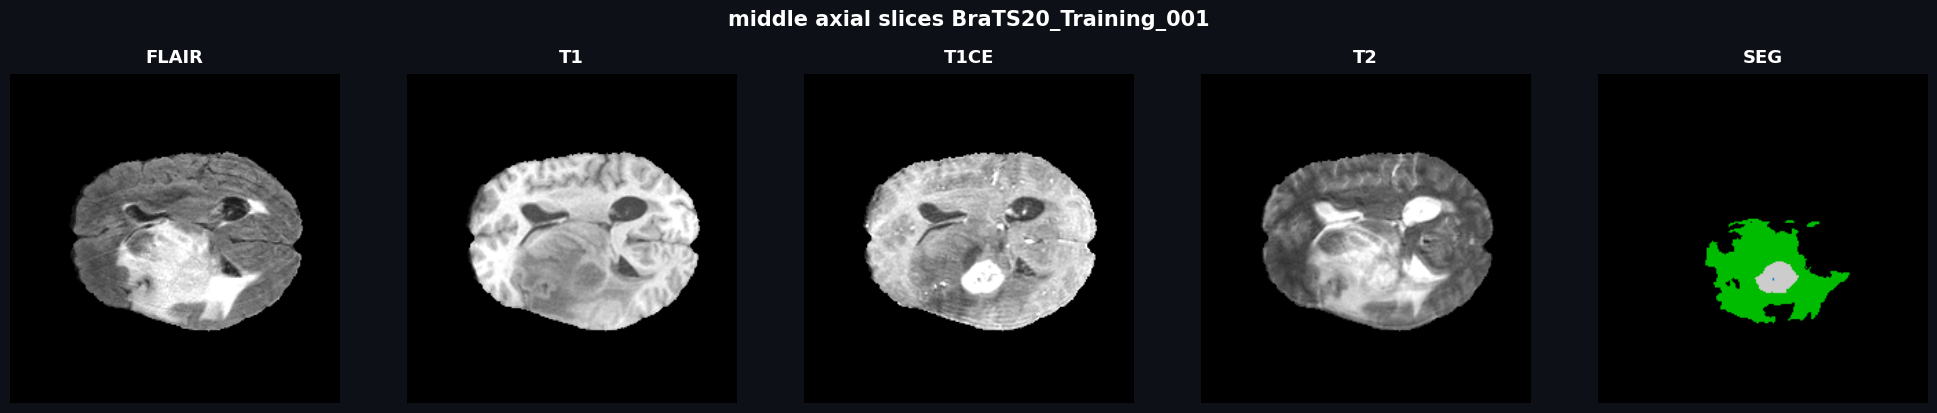

In [20]:
plot_middle_slices(folders, SAMPLE_ID)

Cross-modality shape & orientation consistency check

In [21]:
def consistency_check(folders: list[Path]):
    issues = []

    for folder in tqdm.tqdm(folders):
        shapes, affines = {}, {}
        for mod in MODALITIES + [SEG_SUFFIX]:
            hits = glob.glob(str(folder / f"*_{mod}.nii*"))
            if not hits: continue
            img = load_nii(Path(hits[0]))
            shapes[mod]  = img.shape
            affines[mod] = img.affine

        unique_shapes = set(shapes.values())
        ref_affine = next(iter(affines.values())) if affines else None
        orient_ok = all(np.allclose(a, ref_affine, atol=1e-3) for a in affines.values())

        if len(unique_shapes) > 1 or not orient_ok:
            issues.append({"patient": folder.name, "shapes": shapes, "orient_ok": orient_ok})

    if issues:
        print(f"{len(issues)} patient(s) with inconsistencies:")
        for issue in issues:
            print(f"patient: {issue['patient']}")
            print(f"shapes: {issue['shapes']}")
            print(f"orientation match: {issue['orient_ok']}")
    else:
        print(f"all {len(folders)} patients have consistent shape & orientation across modalities")

In [22]:
consistency_check(folders)

100%|██████████| 369/369 [00:14<00:00, 24.89it/s]

all 369 patients have consistent shape & orientation across modalities


Tumor presence validation & volume per patient

In [23]:
def tumor_analysis(folders: list[Path]):
    with_tumor, without_tumor = [], []
    volumes = []

    for folder in tqdm.tqdm(folders):
        hits = glob.glob(str(folder / "*_seg.nii*"))
        if not hits: continue
        img  = load_nii(Path(hits[0]))
        data = get_data(img).astype(np.int32)
        hdr  = img.header
        vox_vol_mm3 = float(np.prod(hdr.get_zooms()[:3]))

        tumor_mask = data > 0
        n_tumor    = int(tumor_mask.sum())

        if n_tumor > 0:
            with_tumor.append(folder.name)
            vol = n_tumor * vox_vol_mm3
            volumes.append((folder.name, vol))
        else:
            without_tumor.append(folder.name)

    total = len(with_tumor) + len(without_tumor)
    print(f"total patients analysed: {total}")
    print(f"with tumor: {len(with_tumor)} ({100*len(with_tumor)/total:.1f}%)")
    print(f"without tumor: {len(without_tumor)} ({100*len(without_tumor)/total:.1f}%)")

    if without_tumor:
        print(f"patients with no tumor label:")
        for p in without_tumor: print(f" – {p}")

    if volumes:
        vols = [v for _, v in volumes]
        print(f"tumor volume (mm³) across patients with tumor:")
        print(f"min: {min(vols):>12,.1f}")
        print(f"max: {max(vols):>12,.1f}")
        print(f"mean: {np.mean(vols):>12,.1f}")
        print(f"median: {np.median(vols):>12,.1f}")
        print(f"std: {np.std(vols):>12,.1f}")

        print(f"per-patient tumor volume (first 20):")
        print(f"{'patient':35s} {'volume (mm³)':>14s}")
        for name, vol in volumes[:20]:
            print(f"{name:35s}{vol:>14,.1f}")
        if len(volumes) > 20:
            print(f" and {len(volumes)-20} more patients")

    if volumes:
        vols_arr = np.array([v for _, v in volumes])
        fig, ax = plt.subplots(figsize=(9, 4))
        fig.patch.set_facecolor("#0d1117")
        ax.set_facecolor("#161b22")
        ax.hist(vols_arr / 1000, bins=30, color="#58a6ff", edgecolor="#0d1117", linewidth=0.5)
        ax.set_xlabel("tumor volume (cm³)", color="white")
        ax.set_ylabel("number of patients", color="white")
        ax.set_title("distr of tumor volumes across patients", color="white", fontweight="bold")
        ax.tick_params(colors="white")
        for spine in ax.spines.values(): spine.set_color("#30363d")
        plt.tight_layout()
        plt.show()

100%|██████████| 369/369 [00:06<00:00, 56.02it/s]


total patients analysed: 368
with tumor: 368 (100.0%)
without tumor: 0 (0.0%)
tumor volume (mm³) across patients with tumor:
min:      7,285.0
max:    361,783.0
mean:     99,442.1
median:     90,674.0
std:     59,395.2
per-patient tumor volume (first 20):
patient                               volume (mm³)
BraTS20_Training_001                    211,979.0
BraTS20_Training_002                     67,008.0
BraTS20_Training_003                     29,807.0
BraTS20_Training_004                    103,496.0
BraTS20_Training_005                     21,963.0
BraTS20_Training_006                    139,230.0
BraTS20_Training_007                     39,772.0
BraTS20_Training_008                     33,446.0
BraTS20_Training_009                    183,094.0
BraTS20_Training_010                     44,582.0
BraTS20_Training_011                     55,130.0
BraTS20_Training_012                     32,051.0
BraTS20_Training_013                     46,339.0
BraTS20_Training_014                     80

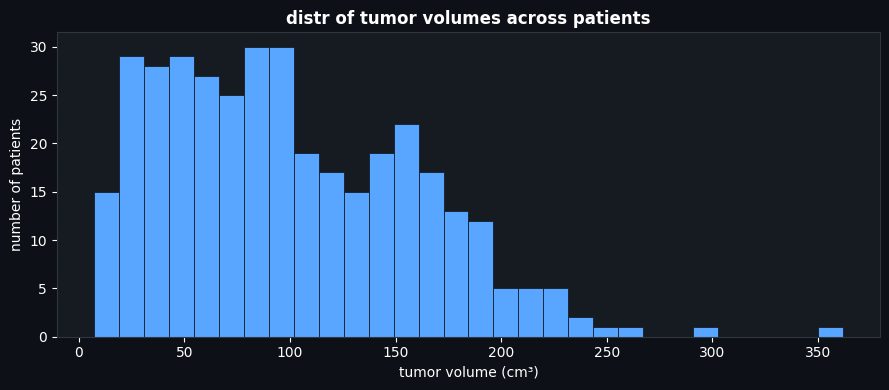

In [24]:
tumor_analysis(folders)